# ZeroER feature space — t-SNE exploration (manual features vs. precomputed LLM embeddings)

Two feature spaces per candidate pair:

1. **manual sim-features** — the live-pipeline per-pair similarity vector
   (`zeroer_features.build_zeroer_features`, the exact ZeroER/Magellan features);

2. **precomputed embeddings** — record vectors embedded offline by large
   embedding LLMs (Qwen3, F2LLM, KaLM, harrier, nemotron, …) and dropped under
   `datasets/embeddings/<dataset>/<model>_{left,right}.npy` (filename starting with
   the embedding-model name), row-aligned with the original tables. Each *pair* is
   represented by `|u − v|` of the two L2-normalised record embeddings — read
   straight off disk, nothing is embedded live.

Each dataset is written out as a static `.png` grid, `and a tidy`.parquet`; the Streamlit app `tsne_dashboard.py` reads the
parquet so you can pick a point and inspect the original record pair column by
column.

In [1]:
import os, sys, glob
sys.path.insert(0, os.path.abspath(".."))   # ZeroER/ — for its top-level modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from data import DATASETS, load_data
from estimator import ZeroEREstimator
from zeroer_features import build_zeroer_features

# --- config ---------------------------------------------------------------
DATASETS_TO_RUN = list(DATASETS)            # all five benchmarks
N_NEGATIVES = 6000          # non-matches kept (all matches are always kept)
BLOCKER     = "standard"    # will experiment with PLM blocker as well at some point
SEED        = 0
OUT_DIR = os.path.abspath(os.path.join("..", "outputs", "tsne_notebook"))
# Precomputed embeddings, one .npy per side per model, the filename starting
# with the embedding-model name:
#   datasets/embeddings/<dataset>/<org>_<model>_{left,right}.npy
# Rows are aligned with left.csv / right.csv (i.e. with data.entities), so they
# index straight into the same positional `pairs` the manual path uses.
EMB_DIR = os.path.abspath("embeddings")
os.makedirs(OUT_DIR, exist_ok=True)
print("cwd:", os.getcwd())
print("saving figures + exports to:", OUT_DIR)
print("precomputed embeddings from:", EMB_DIR)

/home/mda4172/Projects/data-env/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


cwd: /home/mda4172/Projects/pyJedAI/ZeroER/datasets
saving figures + exports to: /home/mda4172/Projects/pyJedAI/ZeroER/outputs/tsne_notebook
precomputed embeddings from: /home/mda4172/Projects/pyJedAI/ZeroER/datasets/embeddings


## 1. Candidate pairs + gold labels

Positives = all gold matches. Negatives = the *hard* non-matches that survive
the blocker (what the matcher actually has to reject), subsampled to
`N_NEGATIVES`. The same pair set feeds all four panels, so they're comparable.

In [2]:
def gold_pairs(data):
    """Gold matches as positional (left_idx, right_idx) tuples into data.entities."""
    out = []
    for _, (lid, rid) in data.ground_truth.iterrows():
        if lid in data._ids_mapping_1 and rid in data._ids_mapping_2:
            out.append((data._ids_mapping_1[lid], data._ids_mapping_2[rid]))
    return out


def build_pairs_and_labels(data, n_negatives=N_NEGATIVES, blocker=BLOCKER, seed=SEED):
    gold = gold_pairs(data)
    gold_set = {frozenset(p) for p in gold}

    est = ZeroEREstimator(blocker=blocker)          # 'standard' => no PLM download
    blocks = est.build_blocks(data)
    cand = [(eid, c) for eid, cs in blocks.items() for c in cs]

    pos = [p for p in cand if frozenset(p) in gold_set]
    neg = [p for p in cand if frozenset(p) not in gold_set]
    kept = {frozenset(p) for p in pos}
    blocking_recall = len(kept) / max(len(gold_set), 1)   # upper bound on F1
    pos = pos + [p for p in gold if frozenset(p) not in kept]   # re-add dropped golds

    rng = np.random.default_rng(seed)
    if len(neg) > n_negatives:
        neg = [neg[i] for i in rng.choice(len(neg), n_negatives, replace=False)]

    pairs = pos + neg
    labels = np.concatenate([np.ones(len(pos), int), np.zeros(len(neg), int)])
    info = dict(blocking_recall=round(blocking_recall, 3), n_pos=len(pos), n_neg=len(neg))
    return pairs, labels, info

## 2. Feature spaces

`tsne_2d` standardises, PCA-reduces high-dim embedding vectors to 50-D, then projects to 2-D. 
`manual_features` reuses the live pipeline;
`precomputed_pair_vectors` loads a model's offline `.npy` record vectors and forms `|u − v|`
per pair, with `precomputed_models` discovering every model present under `embeddings/<dataset>`.

In [3]:
def tsne_2d(X, seed=SEED):
    Xs = StandardScaler().fit_transform(X)
    if Xs.shape[1] > 50:                       # de-noise high-dim embedding space first
        Xs = PCA(n_components=50, random_state=seed).fit_transform(Xs)
    perp = max(5.0, min(30.0, (len(Xs) - 1) / 3.0))
    return TSNE(n_components=2, perplexity=perp, init="pca",
                learning_rate="auto", random_state=seed).fit_transform(Xs)


def manual_features(data, attrs, pairs):
    fm = build_zeroer_features(       # rows aligned with `pairs`
        pairs, data.entities, attrs,
        dataset_limit=None if data.is_dirty_er else data.dataset_limit)
    return fm.values, fm.shape[1]


def precomputed_models(ds):
    """(stem, hf_id) for each precomputed model under embeddings/<ds>, by name.

    ``stem`` is the on-disk filename minus the ``_left.npy`` suffix — it starts
    with the embedding-model name (e.g. ``Qwen_Qwen3-Embedding-4B``); the HF id
    just restores the first ``_`` to the ``org/model`` slash so the dashboard can
    show a real model name.
    """
    out = []
    for p in sorted(glob.glob(os.path.join(EMB_DIR, ds, "*_left.npy"))):
        stem = os.path.basename(p)[:-len("_left.npy")]
        out.append((stem, stem.replace("_", "/", 1)))
    return out


def precomputed_pair_vectors(data, pairs, stem, ds):
    """Load precomputed record embeddings and form |u-v| per pair.

    The two .npy files are row-aligned with left.csv / right.csv, i.e. with
    ``data.entities``: left rows occupy positions ``0..N1-1`` and right rows
    ``N1..N1+N2-1`` — exactly the positional indices stored in ``pairs``. We
    mmap and gather only the referenced rows (right tables can be tens of
    thousands of records) and re-normalise defensively before differencing.
    """
    N1 = data.num_of_entities_1
    L = np.load(os.path.join(EMB_DIR, ds, f"{stem}_left.npy"),  mmap_mode="r")
    R = np.load(os.path.join(EMB_DIR, ds, f"{stem}_right.npy"), mmap_mode="r")

    def gather(idxs):
        out = np.empty((len(idxs), L.shape[1]), dtype=np.float32)
        for k, idx in enumerate(idxs):
            out[k] = L[idx] if idx < N1 else R[idx - N1]
        return out

    u = gather([a for a, _ in pairs])
    v = gather([b for _, b in pairs])
    u /= np.linalg.norm(u, axis=1, keepdims=True)
    v /= np.linalg.norm(v, axis=1, keepdims=True)
    return np.abs(u - v), L.shape[1]

## 3. Plotting

In [4]:
def scatter(ax, coords, labels, title):
    neg, pos = coords[labels == 0], coords[labels == 1]
    ax.scatter(neg[:, 0], neg[:, 1], s=6, c="#9bb7d4", alpha=0.35,
               linewidths=0, label=f"non-match ({len(neg)})")
    ax.scatter(pos[:, 0], pos[:, 1], s=12, c="#d62728", alpha=0.8,
               linewidths=0, label=f"match ({len(pos)})")
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc="best", fontsize=7, framealpha=0.8, markerscale=1.5)

In [5]:
def pair_records(data, attrs, pairs, labels):
    """One row per pair: label, original ids, and each attribute's left/right value."""
    inv = {v: k for k, v in data._ids_mapping_1.items()}
    inv.update({v: k for k, v in data._ids_mapping_2.items()})
    li, ri = map(np.asarray, zip(*pairs))
    cols = {
        "label":    labels.astype(int),
        "left_id":  [inv.get(int(i)) for i in li],
        "right_id": [inv.get(int(i)) for i in ri],
    }
    for a in attrs:
        col = data.entities[a].astype(str).to_numpy()
        cols[f"left_{a}"], cols[f"right_{a}"] = col[li], col[ri]
    return pd.DataFrame(cols)

## 4. Run all feature spaces per dataset

Per dataset: build the shared pair set once, then t-SNE the manual features and
every precomputed `|u−v|` space found under `embeddings/<dataset>`.

=== fodors_zagats ===


/home/mda4172/Projects/data-env/lib/python3.10/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


  112 matches / 349 non-matches | blocking recall 1.0
  precomputed Octen_Octen-Embedding-8B (Octen/Octen-Embedding-8B) ...
  precomputed Qwen_Qwen3-Embedding-4B (Qwen/Qwen3-Embedding-4B) ...
  precomputed Qwen_Qwen3-Embedding-8B (Qwen/Qwen3-Embedding-8B) ...
  precomputed codefuse-ai_F2LLM-v2-14B (codefuse-ai/F2LLM-v2-14B) ...
  precomputed codefuse-ai_F2LLM-v2-4B (codefuse-ai/F2LLM-v2-4B) ...
  precomputed codefuse-ai_F2LLM-v2-8B (codefuse-ai/F2LLM-v2-8B) ...
  precomputed microsoft_harrier-oss-v1-0.6b (microsoft/harrier-oss-v1-0.6b) ...
  precomputed microsoft_harrier-oss-v1-27b (microsoft/harrier-oss-v1-27b) ...
  precomputed nvidia_llama-embed-nemotron-8b (nvidia/llama-embed-nemotron-8b) ...
  precomputed tencent_KaLM-Embedding-Gemma3-12B-2511 (tencent/KaLM-Embedding-Gemma3-12B-2511) ...


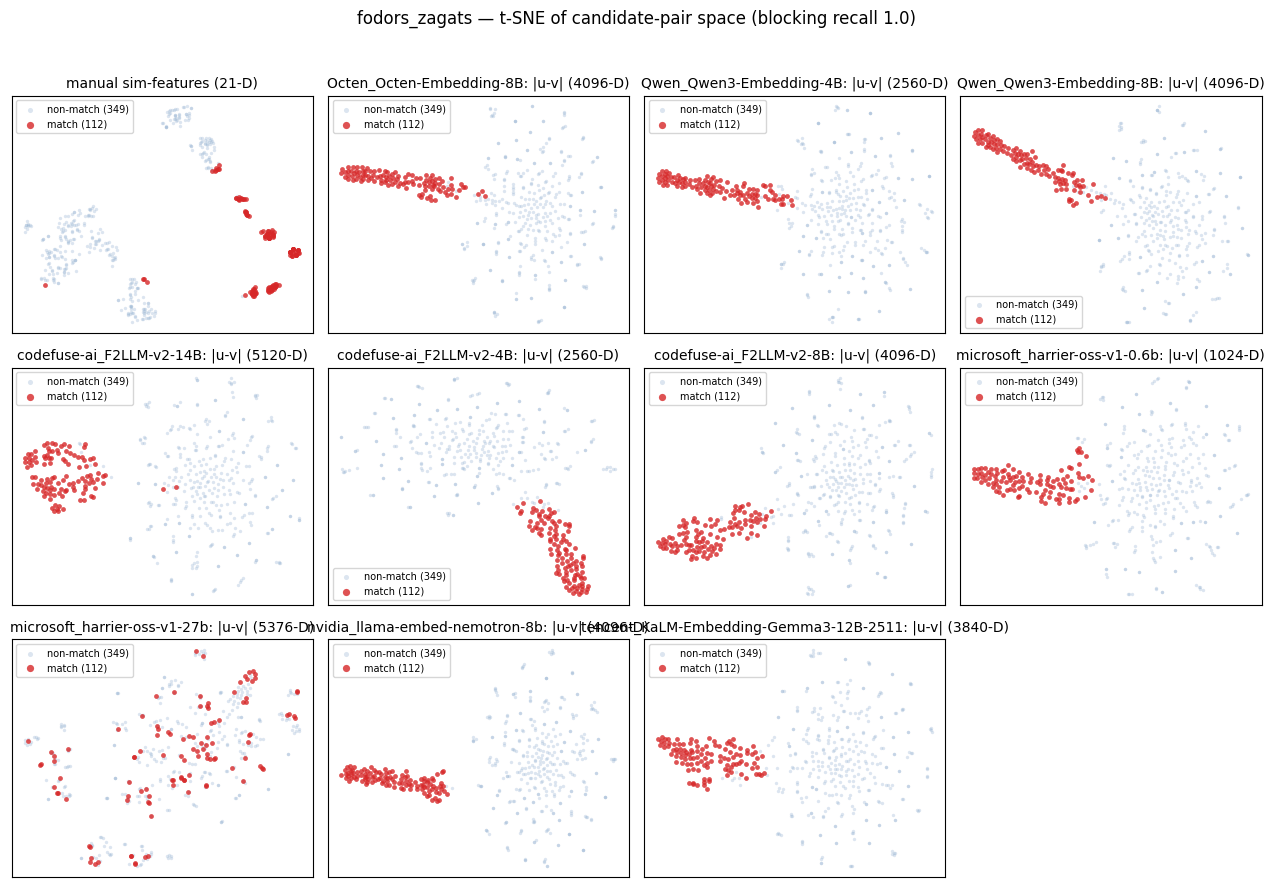

  saved /home/mda4172/Projects/pyJedAI/ZeroER/outputs/tsne_notebook/tsne_fodors_zagats.parquet, /home/mda4172/Projects/pyJedAI/ZeroER/outputs/tsne_notebook/tsne_fodors_zagats.png
=== dblp_acm ===
  2224 matches / 6000 non-matches | blocking recall 1.0
  precomputed Octen_Octen-Embedding-8B (Octen/Octen-Embedding-8B) ...
  precomputed Qwen_Qwen3-Embedding-4B (Qwen/Qwen3-Embedding-4B) ...
  precomputed Qwen_Qwen3-Embedding-8B (Qwen/Qwen3-Embedding-8B) ...
  precomputed codefuse-ai_F2LLM-v2-14B (codefuse-ai/F2LLM-v2-14B) ...
  precomputed codefuse-ai_F2LLM-v2-4B (codefuse-ai/F2LLM-v2-4B) ...
  precomputed codefuse-ai_F2LLM-v2-8B (codefuse-ai/F2LLM-v2-8B) ...
  precomputed microsoft_harrier-oss-v1-0.6b (microsoft/harrier-oss-v1-0.6b) ...
  precomputed microsoft_harrier-oss-v1-27b (microsoft/harrier-oss-v1-27b) ...
  precomputed nvidia_llama-embed-nemotron-8b (nvidia/llama-embed-nemotron-8b) ...
  precomputed tencent_KaLM-Embedding-Gemma3-12B-2511 (tencent/KaLM-Embedding-Gemma3-12B-2511) ..

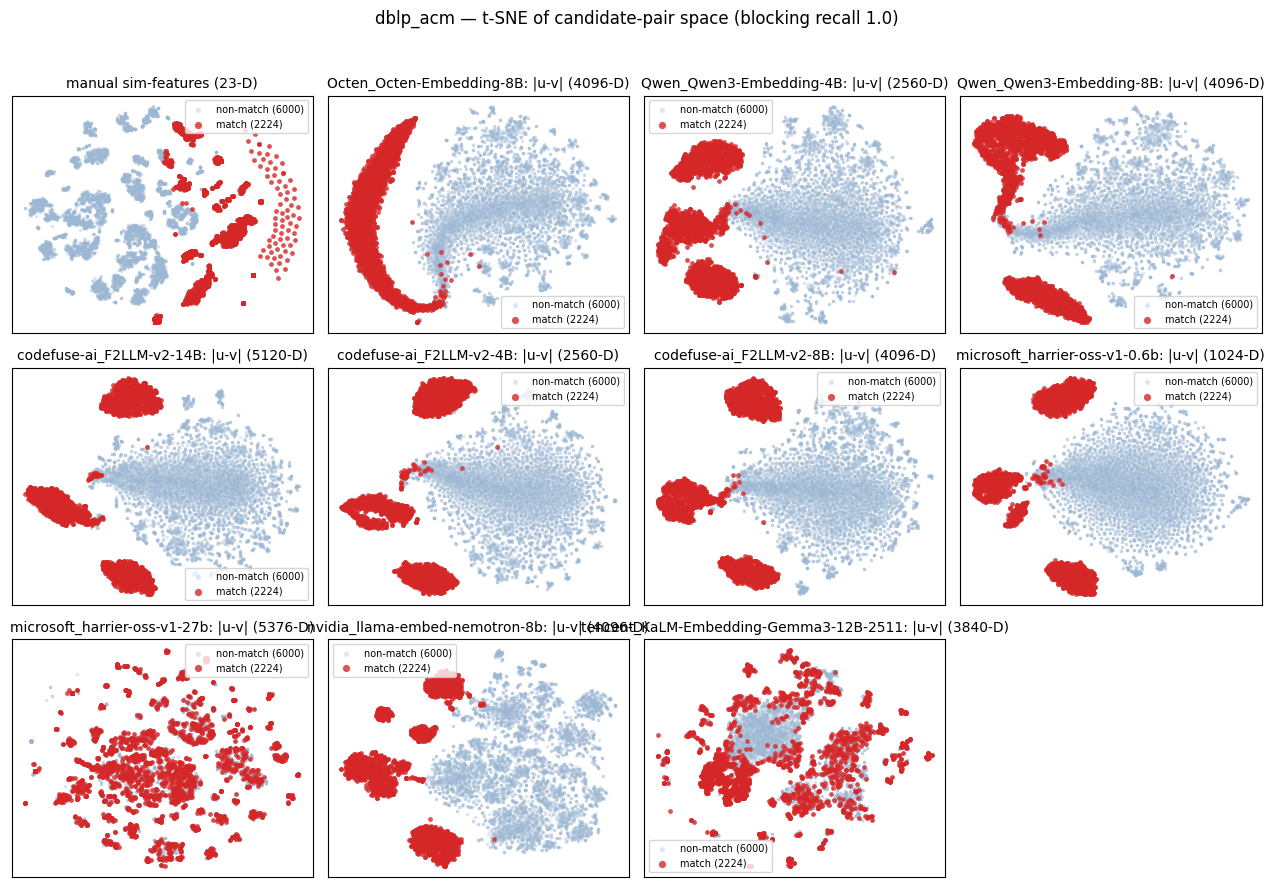

  saved /home/mda4172/Projects/pyJedAI/ZeroER/outputs/tsne_notebook/tsne_dblp_acm.parquet, /home/mda4172/Projects/pyJedAI/ZeroER/outputs/tsne_notebook/tsne_dblp_acm.png
=== dblp_scholar ===
  5347 matches / 6000 non-matches | blocking recall 0.996
  precomputed Octen_Octen-Embedding-8B (Octen/Octen-Embedding-8B) ...
  precomputed Qwen_Qwen3-Embedding-4B (Qwen/Qwen3-Embedding-4B) ...
  precomputed Qwen_Qwen3-Embedding-8B (Qwen/Qwen3-Embedding-8B) ...
  precomputed codefuse-ai_F2LLM-v2-14B (codefuse-ai/F2LLM-v2-14B) ...
  precomputed codefuse-ai_F2LLM-v2-4B (codefuse-ai/F2LLM-v2-4B) ...
  precomputed codefuse-ai_F2LLM-v2-8B (codefuse-ai/F2LLM-v2-8B) ...
  precomputed microsoft_harrier-oss-v1-0.6b (microsoft/harrier-oss-v1-0.6b) ...
  precomputed microsoft_harrier-oss-v1-27b (microsoft/harrier-oss-v1-27b) ...
  precomputed nvidia_llama-embed-nemotron-8b (nvidia/llama-embed-nemotron-8b) ...
  precomputed tencent_KaLM-Embedding-Gemma3-12B-2511 (tencent/KaLM-Embedding-Gemma3-12B-2511) ...


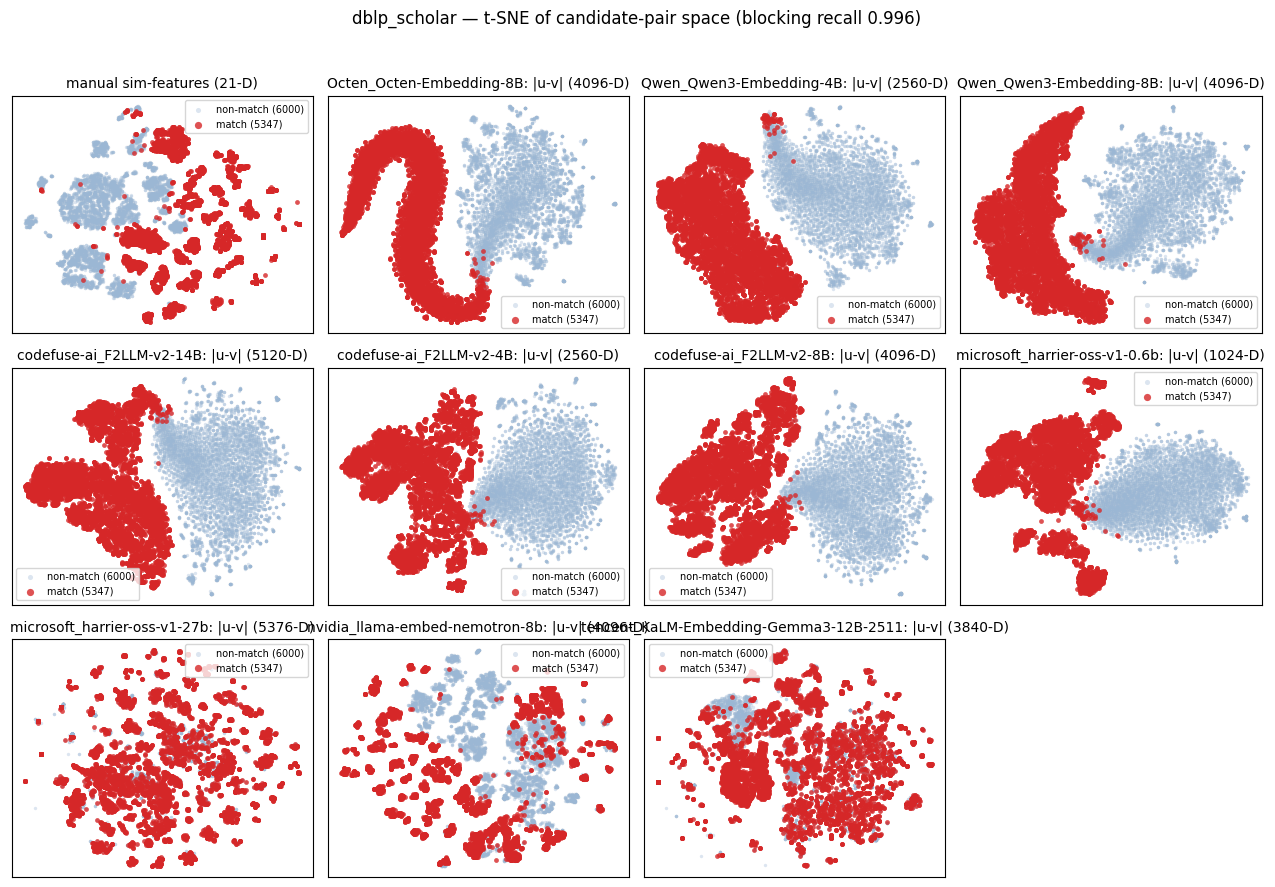

  saved /home/mda4172/Projects/pyJedAI/ZeroER/outputs/tsne_notebook/tsne_dblp_scholar.parquet, /home/mda4172/Projects/pyJedAI/ZeroER/outputs/tsne_notebook/tsne_dblp_scholar.png
=== abt_buy ===
  1097 matches / 6000 non-matches | blocking recall 0.981
  precomputed Octen_Octen-Embedding-8B (Octen/Octen-Embedding-8B) ...
  precomputed Qwen_Qwen3-Embedding-4B (Qwen/Qwen3-Embedding-4B) ...
  precomputed Qwen_Qwen3-Embedding-8B (Qwen/Qwen3-Embedding-8B) ...
  precomputed codefuse-ai_F2LLM-v2-14B (codefuse-ai/F2LLM-v2-14B) ...
  precomputed codefuse-ai_F2LLM-v2-4B (codefuse-ai/F2LLM-v2-4B) ...
  precomputed codefuse-ai_F2LLM-v2-8B (codefuse-ai/F2LLM-v2-8B) ...
  precomputed microsoft_harrier-oss-v1-0.6b (microsoft/harrier-oss-v1-0.6b) ...
  precomputed microsoft_harrier-oss-v1-27b (microsoft/harrier-oss-v1-27b) ...
  precomputed nvidia_llama-embed-nemotron-8b (nvidia/llama-embed-nemotron-8b) ...
  precomputed tencent_KaLM-Embedding-Gemma3-12B-2511 (tencent/KaLM-Embedding-Gemma3-12B-2511) ...

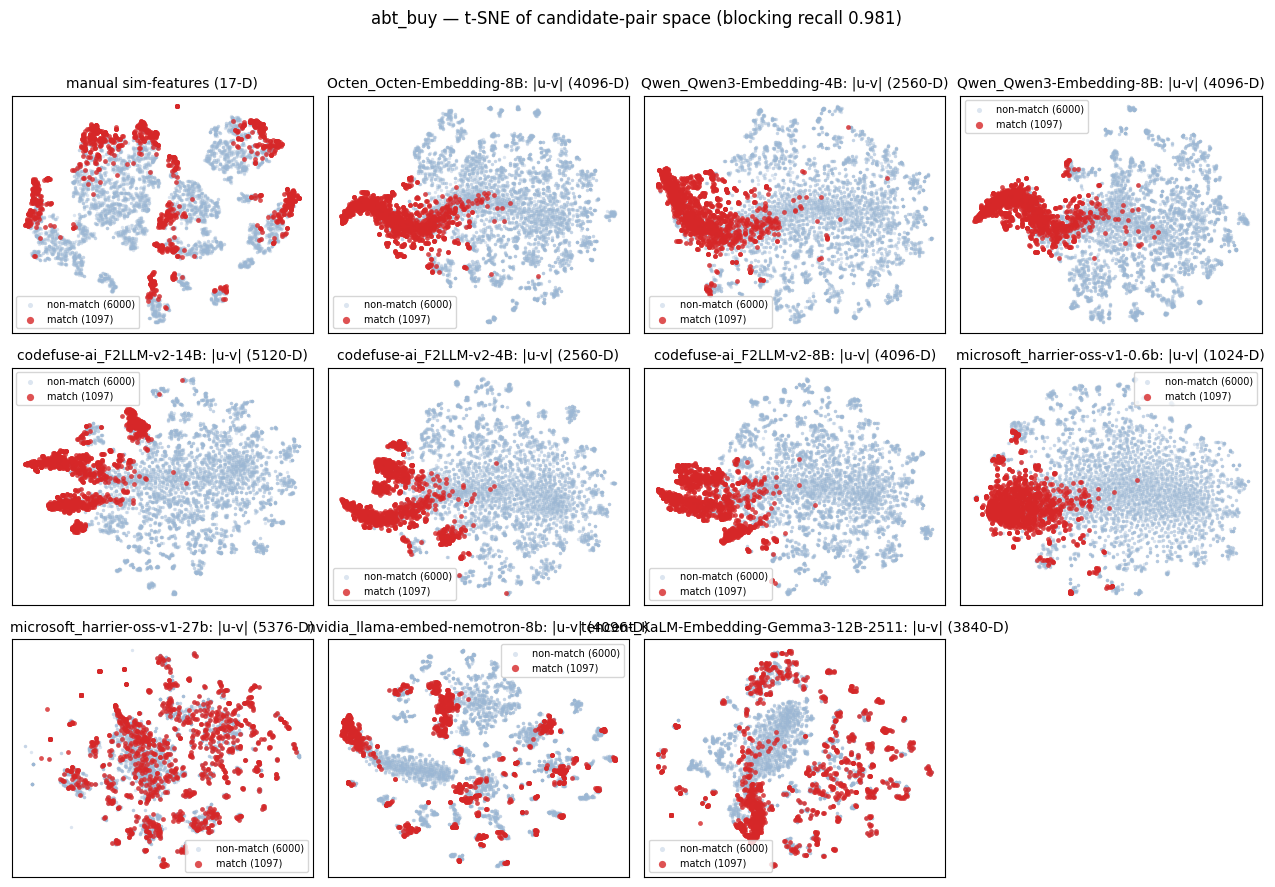

  saved /home/mda4172/Projects/pyJedAI/ZeroER/outputs/tsne_notebook/tsne_abt_buy.parquet, /home/mda4172/Projects/pyJedAI/ZeroER/outputs/tsne_notebook/tsne_abt_buy.png
=== amazon_googleproducts ===
  1300 matches / 6000 non-matches | blocking recall 0.944
  precomputed Octen_Octen-Embedding-8B (Octen/Octen-Embedding-8B) ...
  precomputed Qwen_Qwen3-Embedding-4B (Qwen/Qwen3-Embedding-4B) ...
  precomputed Qwen_Qwen3-Embedding-8B (Qwen/Qwen3-Embedding-8B) ...
  precomputed codefuse-ai_F2LLM-v2-14B (codefuse-ai/F2LLM-v2-14B) ...
  precomputed codefuse-ai_F2LLM-v2-4B (codefuse-ai/F2LLM-v2-4B) ...
  precomputed codefuse-ai_F2LLM-v2-8B (codefuse-ai/F2LLM-v2-8B) ...
  precomputed microsoft_harrier-oss-v1-0.6b (microsoft/harrier-oss-v1-0.6b) ...
  precomputed microsoft_harrier-oss-v1-27b (microsoft/harrier-oss-v1-27b) ...
  precomputed nvidia_llama-embed-nemotron-8b (nvidia/llama-embed-nemotron-8b) ...
  precomputed tencent_KaLM-Embedding-Gemma3-12B-2511 (tencent/KaLM-Embedding-Gemma3-12B-2511)

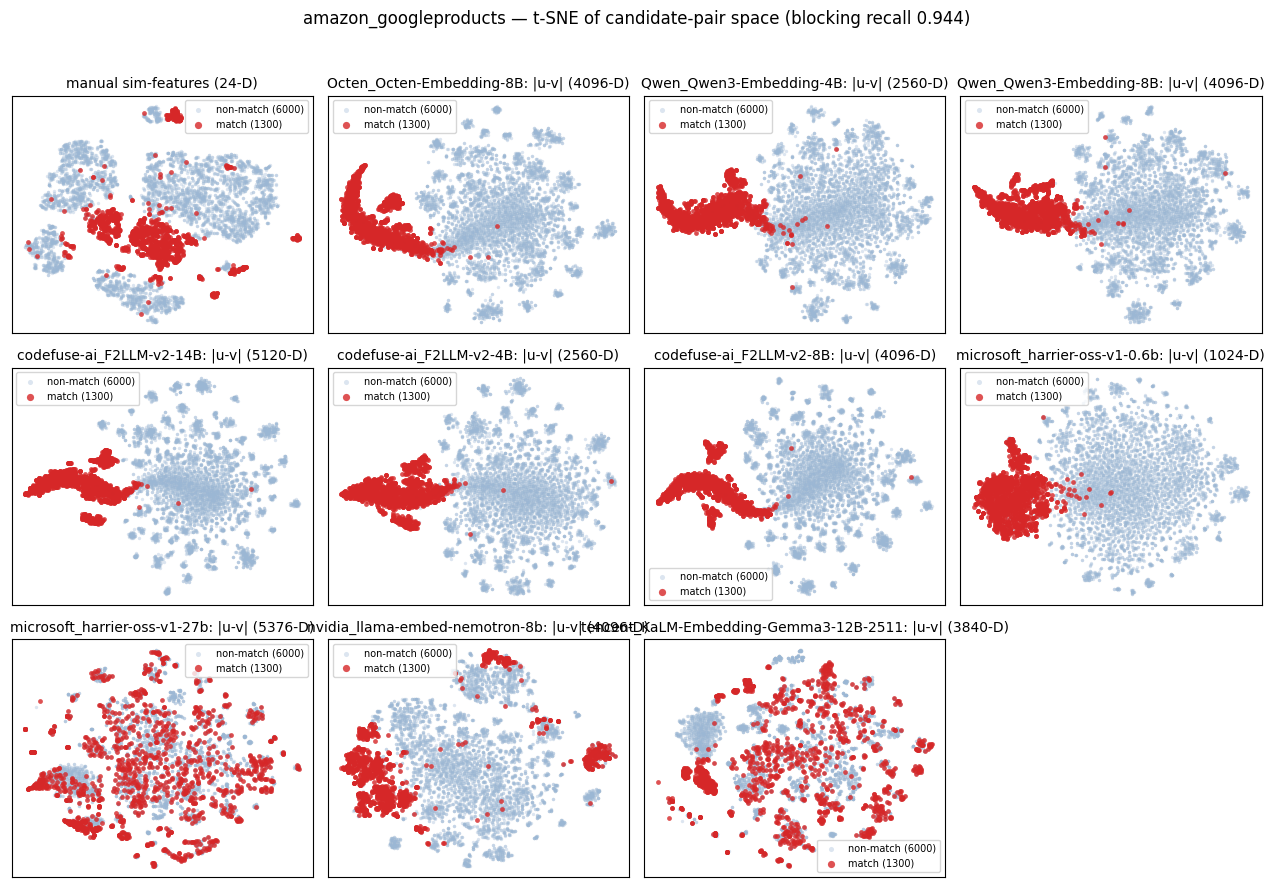

  saved /home/mda4172/Projects/pyJedAI/ZeroER/outputs/tsne_notebook/tsne_amazon_googleproducts.parquet, /home/mda4172/Projects/pyJedAI/ZeroER/outputs/tsne_notebook/tsne_amazon_googleproducts.png
wrote combined export: /home/mda4172/Projects/pyJedAI/ZeroER/outputs/tsne_notebook/tsne_all.parquet


In [6]:
all_exports = []
for ds in DATASETS_TO_RUN:
    print(f"=== {ds} ===", flush=True)
    data = load_data(ds)
    attrs = DATASETS[ds]["attributes"]
    pairs, labels, info = build_pairs_and_labels(data)
    print(f"  {info['n_pos']} matches / {info['n_neg']} non-matches "
          f"| blocking recall {info['blocking_recall']}", flush=True)

    base = pair_records(data, attrs, pairs, labels)   # constant across methods

    methods = []                                       # (name, dim, coords, model_id)
    Xm, dim = manual_features(data, attrs, pairs)
    methods.append(("manual", dim, tsne_2d(Xm), "manual sim-features"))
    for stem, hf in precomputed_models(ds):            # precomputed embeddings from the folder
        print(f"  precomputed {stem} ({hf}) ...", flush=True)
        Xp, dim = precomputed_pair_vectors(data, pairs, stem, ds)
        methods.append((stem, dim, tsne_2d(Xp), hf))

    # --- tidy long export: one row per (pair x method) ---------------------
    # `model_id` carries the actual HF id (or "manual sim-features") so the
    # dashboard's PLM dropdown can show real model names, not just short codes.
    frames = []
    for name, dim, coords, model_id in methods:
        f = base.copy()
        f.insert(0, "dataset", ds)
        f.insert(1, "method", name)
        f.insert(2, "model_id", model_id)
        f.insert(3, "dim", dim)
        f["x"], f["y"] = coords[:, 0], coords[:, 1]
        frames.append(f)
    export = pd.concat(frames, ignore_index=True)
    all_exports.append(export)
    pq = os.path.join(OUT_DIR, f"tsne_{ds}.parquet")
    export.to_parquet(pq, index=False)

    # --- static overview grid (adapts to N panels) ------------------------
    n = len(methods); ncols = 4; nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.0 * nrows),
                             squeeze=False)
    for ax, (name, dim, coords, _mid) in zip(axes.flat, methods):
        title = (f"manual sim-features ({dim}-D)" if name == "manual"
                 else f"{name}: |u-v| ({dim}-D)")
        scatter(ax, coords, labels, title)
    for ax in axes.flat[n:]:
        ax.axis("off")
    fig.suptitle(f"{ds} — t-SNE of candidate-pair space "
                 f"(blocking recall {info['blocking_recall']})", fontsize=12)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    png = os.path.join(OUT_DIR, f"tsne_{ds}.png")
    fig.savefig(png, dpi=150)
    plt.show()

    print(f"  saved {pq}, {png}", flush=True)

combined = os.path.join(OUT_DIR, "tsne_all.parquet")
pd.concat(all_exports, ignore_index=True).to_parquet(combined, index=False)
print("wrote combined export:", combined, flush=True)